In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

In [2]:

train_input_file = "C:/Users/pbarb/Documents/arts_et_metiers/Paris/PJE/Finance/input_training.xlsx"
train_output_file = "C:/Users/pbarb/Documents/arts_et_metiers/Paris/PJE/Finance/output_training.xlsx"
test_input_file = "C:/Users/pbarb/Documents/arts_et_metiers/Paris/PJE/Finance/input_test.xlsx"

In [6]:
train_inputs = pd.read_excel(train_input_file, sheet_name='input_training')  

KeyboardInterrupt: 

In [4]:
train_outputs = pd.read_excel(train_output_file, sheet_name='output_training')

In [5]:
test_inputs = pd.read_excel(test_input_file, sheet_name='input_test')

In [163]:
df = train_inputs[train_inputs['ID']<100000]
train_out = train_outputs[train_outputs['ID']<100000]
test_inp = test_inputs[test_inputs['ID']<1100000]

# Data cleaning of the null or NaN data

In [165]:
import pandas as pd
import numpy as np

cols_rendement = ['r' + str(i) for i in range(0, 53)]

df[cols_rendement] = df[cols_rendement].replace(0, np.nan)

df = df.dropna(how='all', subset=cols_rendement)

def remplacer_par_moyenne(df, col):
    for i in df.index:
        if pd.isna(df.at[i, col]):
            
            prev_val = df.at[i - 1, col] if i - 1 in df.index else np.nan
            
            next_val = df.at[i + 1, col] if i + 1 in df.index else np.nan
            
            
            if pd.isna(prev_val) and not pd.isna(next_val):
                df.at[i, col] = next_val
            elif not pd.isna(prev_val) and pd.isna(next_val):
                df.at[i, col] = prev_val
            elif not pd.isna(prev_val) and not pd.isna(next_val):
                df.at[i, col] = (prev_val + next_val) / 2


for col in cols_rendement:
    remplacer_par_moyenne(df, col)
    
df.loc[df['r0'] == 0.00, 'r0'] = df['r1']

C:\Users\pbarb\AppData\Local\Temp\ipykernel_71748\2115262942.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cols_rendement] = df[cols_rendement].replace(0, np.nan)


In [9]:
import pandas as pd
import numpy as np

cols_rendement = ['r' + str(i) for i in range(1, 53)]

threshold = len(cols_rendement) / 3
df = df.dropna(thresh=threshold, subset=cols_rendement)

for i, row in df.iterrows():
    
    mean_val = row[cols_rendement].mean()
    
    df.loc[i, cols_rendement] = row[cols_rendement].fillna(mean_val)


KeyboardInterrupt: 

# Outliers : Let's remove the non relevant data (lower and upper percentiles)

In [109]:
import pandas as pd

columns = ['r' + str(i) for i in range(1, 53)]

for col in columns:
    lower_percentile = df[col].quantile(0.001)
    upper_percentile = df[col].quantile(0.009)
    
    df[col] = df[col].clip(lower_percentile, upper_percentile)

C:\Users\pbarb\AppData\Local\Temp\ipykernel_71748\1076382613.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].clip(lower_percentile, upper_percentile)


# Let's now show the distribution of null data (as a check)

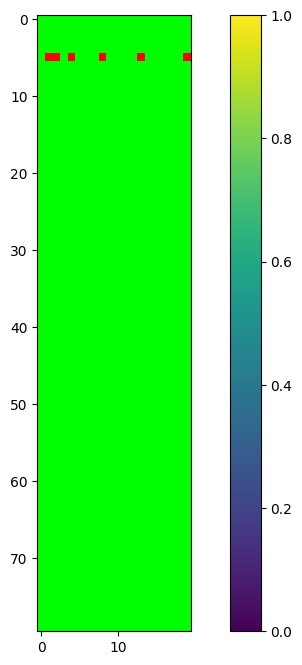

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creation of a mask for each condition
nan_mask = df.isna()
zero_mask = (df == 0)
non_zero_nan_mask = ~(nan_mask | zero_mask)

colors = np.zeros((df.shape[0], df.shape[1], 3))  
colors[nan_mask] = [1, 0, 0]  # Red for NaN
colors[zero_mask] = [232,229, 0]  # Orange for zero
colors[non_zero_nan_mask] = [0, 1, 0]  # Green for non-null

plt.figure(figsize=(10, 8))
plt.imshow(colors[20:100, 20:40])
plt.colorbar()
plt.show()

# Let's visualize the distribution of data for a specific 'r' (5 minutes interval)

Text(0, 0.5, 'Fréquence')

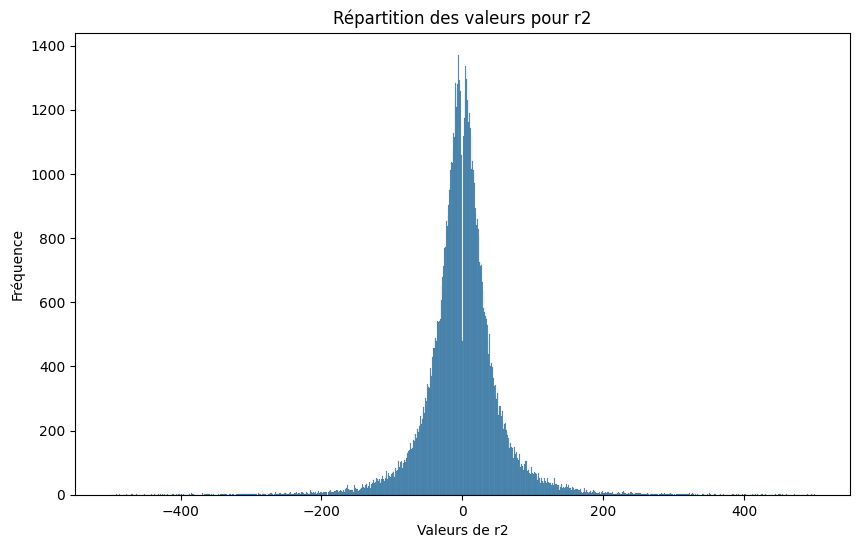

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns 

plt.figure(figsize=(10, 6))
sns.histplot(df['r2'], bins=1000, binrange=(-500, 500))
plt.title("Répartition des valeurs pour r2")
plt.xlabel('Valeurs de r2')
plt.ylabel('Fréquence')

In [64]:
df

,ID,day,equity,r0,r1,r2,r3,r4,r5,r6,...,r43,r44,r45,r46,r47,r48,r49,r50,r51,r52
0,0,249,1488,-9.760,NaN,-12.210,46.440,34.08,NaN,41.24,...,-4.830,-16.920,-4.840,4.84,NaN,7.26,-9.68,-19.38,9.71,26.680
1,1,272,107,-9.760,NaN,-12.210,46.440,34.08,-22.140,41.24,...,-4.830,-16.920,-4.840,4.84,-9.59,7.26,-9.68,-19.38,9.71,26.680
2,2,323,1063,49.850,NaN,-12.210,-26.640,-23.66,-22.140,49.12,...,-6.370,1.590,6.370,-49.32,-9.59,-6.40,22.41,-6.39,7.99,15.960
3,3,302,513,-36.995,-115.18,-19.325,-26.640,9.38,-5.790,49.12,...,-5.865,-9.925,-7.555,-19.27,-15.57,-5.90,5.80,-0.49,-12.24,29.695
4,4,123,1465,-123.840,-115.18,-26.440,-16.095,42.42,10.560,20.99,...,-5.360,-21.440,-21.480,10.78,-21.55,-5.40,-10.81,5.41,-32.47,43.430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,99994,175,1692,-19.740,6.59,12.615,-19.915,-13.16,70.735,7.13,...,-17.230,6.500,-6.490,9.39,-3.23,-0.39,13.03,-6.51,6.51,1.705
99995,99995,248,1689,-135.340,-53.30,45.940,43.200,-31.63,-6.340,59.71,...,-7.810,-6.510,-9.600,17.42,2.61,3.91,1.30,10.43,28.83,-1.300
99996,99996,55,849,103.630,51.81,12.890,-38.610,51.68,-25.740,-12.94,...,25.480,-12.690,-12.710,25.45,-12.69,-12.71,-12.72,-12.77,51.15,-12.720
99997,99997,45,1620,-4.730,-33.07,9.470,4.730,4.73,9.450,-4.72,...,-7.070,-4.720,-4.720,25.45,-12.69,2.36,-4.72,-9.45,51.15,-12.720


In [150]:
(df.isna()).sum().sum()

10409

In [134]:
df.head(20)

,ID,day,equity,r0,r1,r2,r3,r4,r5,r6,...,r43,r44,r45,r46,r47,r48,r49,r50,r51,r52
0,0,249,1488,0.00,NaN,NaN,NaN,0.00,NaN,NaN,...,0.00,0.00,NaN,0.00,NaN,0.00,NaN,NaN,NaN,0.00
1,1,272,107,-9.76,0.00,-12.21,46.44,34.08,0.00,41.24,...,-4.83,-16.92,-4.84,4.84,0.00,7.26,-9.68,-19.38,9.71,26.68
2,2,323,1063,49.85,0.00,0.00,-26.64,-23.66,-22.14,49.12,...,-6.37,1.59,6.37,-49.32,-9.59,-6.40,22.41,-6.39,7.99,15.96
3,3,302,513,0.00,NaN,0.00,0.00,0.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN
4,4,123,1465,-123.84,-115.18,-26.44,0.00,42.42,10.56,0.00,...,-5.36,-21.44,-21.48,10.78,-21.55,-5.40,-10.81,5.41,-32.47,43.43
5,5,343,1279,-26.91,4.76,9.52,-5.55,-7.14,-1.59,-7.14,...,-0.80,0.80,-3.19,3.99,-3.19,-4.79,-5.59,6.39,-6.38,-5.59
6,6,212,185,0.00,-30.67,4.40,-13.19,13.20,26.37,4.38,...,-4.41,0.00,6.62,13.23,0.00,0.00,4.40,13.20,-4.40,4.40
7,7,239,780,110.26,-33.25,-7.81,36.55,-29.47,3.28,17.21,...,12.29,-23.96,7.80,8.62,2.87,-6.97,-12.72,-9.03,-2.47,-18.92
8,8,22,1252,0.00,35.36,-7.05,7.05,-35.31,0.00,NaN,...,NaN,-49.16,0.00,-14.11,35.36,-14.09,0.00,NaN,NaN,0.00
9,9,343,478,-45.65,45.76,13.24,25.71,21.99,-18.98,-6.58,...,4.40,-14.67,-9.55,2.21,13.24,-4.41,-5.14,20.58,1.47,-2.94


In [69]:
train_out.set_index('ID', inplace=True)
df.set_index('ID', inplace = True)

# Remove the associated train_out rows

In [70]:
indices = df.index

train_out = train_out.loc[indices]

In [71]:
df = df[[f'r{i}' for i in range(53)]].values
train_out = train_out['reod'].values
test_inp = test_inp[[f'r{i}' for i in range(53)]].values

In [ ]:
# Encode (-1, 0, 1) in one-hot encoding
label_encoder = LabelEncoder()
train_out_encoded = label_encoder.fit_transform(train_out)
train_out_onehot = to_categorical(train_out_encoded)

In [ ]:
# Divide the data into train & test datasets
X_train, X_val, y_train, y_val = train_test_split(df, train_out_onehot, test_size=0.2, random_state=42)

In [ ]:
# Pretreatment of the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
test_inp_scaled = scaler.transform(test_inp)

In [ ]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, activation='relu', input_shape=(X_train_scaled.shape[1], 1)))
model.add(Dropout(0.2))
model.add(Dense(units=3, activation='softmax'))  # 3 classes pour one-hot encoding

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10)

In [76]:
# Entraîner le modèle
model.fit(np.expand_dims(X_train_scaled, axis=-1), y_train, epochs=20, batch_size=32, callbacks=[early_stopping], validation_data=(np.expand_dims(X_val_scaled, axis=-1), y_val))

Epoch 1/20
1717/2467 [===================>..........] - ETA: 13s - loss: nan - accuracy: 0.3051

KeyboardInterrupt: 

In [ ]:
# Forecasting with the test set
test_predictions = model.predict(np.expand_dims(test_inp_scaled, axis=-1))
test_predictions_classes = label_encoder.inverse_transform(np.argmax(test_predictions, axis=1))

In [ ]:
# Create the dataframe with the forecast returns
output_df = pd.DataFrame({'reod': test_predictions_classes})

In [ ]:
# Save the forecast in an xls file
output_df.to_excel('C:/Users/pbarb/Documents/arts_et_metiers/Paris/PJE/Finance/Y_test_2.xlsx', index=False)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier 

# Crossed validation K-fold
kf = KFold(n_splits=5, random_state=42, shuffle=True) # 5 est un choix courant pour le nombre de folds

scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')

print(f"Scores de chaque fold : {scores}")
print(f"Moyenne des scores : {scores.mean()}")


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

In [139]:
train_inp = df

In [99]:
train_inp.fillna(0, inplace=True)
train_out.fillna(0, inplace=True)
test_inp.fillna(0, inplace=True)

C:\Users\pbarb\AppData\Local\Temp\ipykernel_22536\1276029448.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_inp.fillna(0, inplace=True)
C:\Users\pbarb\AppData\Local\Temp\ipykernel_22536\1276029448.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_out.fillna(0, inplace=True)
C:\Users\pbarb\AppData\Local\Temp\ipykernel_22536\1276029448.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_inp.fillna(0, inplace=True)

In [135]:
test_inp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 843299 entries, 0 to 843298
Data columns (total 56 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      843299 non-null  int64  
 1   day     843299 non-null  int64  
 2   equity  843299 non-null  int64  
 3   r0      797476 non-null  float64
 4   r1      746484 non-null  float64
 5   r2      740829 non-null  float64
 6   r3      749130 non-null  float64
 7   r4      749569 non-null  float64
 8   r5      747841 non-null  float64
 9   r6      751778 non-null  float64
 10  r7      757167 non-null  float64
 11  r8      753221 non-null  float64
 12  r9      753369 non-null  float64
 13  r10     754488 non-null  float64
 14  r11     752338 non-null  float64
 15  r12     754558 non-null  float64
 16  r13     758631 non-null  float64
 17  r14     761805 non-null  float64
 18  r15     757907 non-null  float64
 19  r16     759664 non-null  float64
 20  r17     758125 non-null  float64
 21  r18     75

<AxesSubplot:>

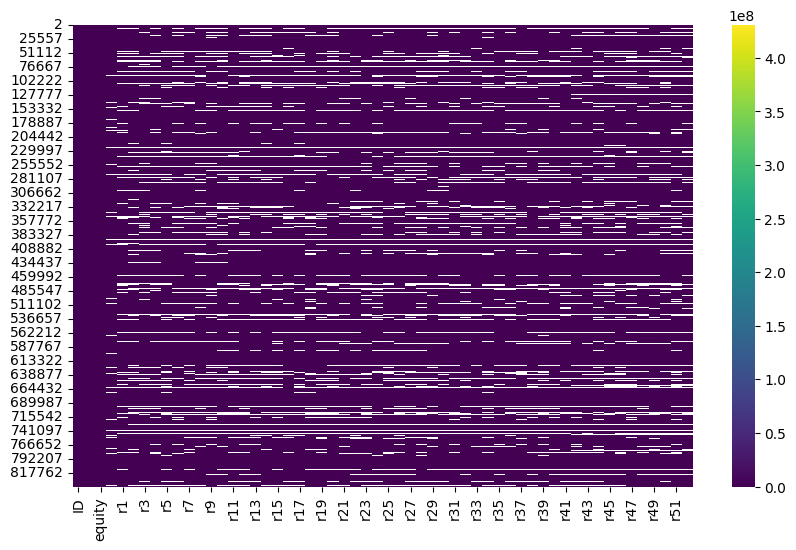

In [ ]:
# Heatmap creation
plt.figure(figsize=(10, 6))  
sns.heatmap(subset_data, cmap='viridis')  

In [43]:
df = train_inputs[train_inputs["equity"]<5]

In [ ]:
# Treshold for the maximum numbers of null values within one row
seuil = len(df.columns) * 0.5

# Delete the rows containing more null values
df_cleaned = df.dropna(axis=0, thresh=seuil)

In [46]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1778 entries, 36 to 841711
Data columns (total 56 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      1778 non-null   int64  
 1   day     1778 non-null   int64  
 2   equity  1778 non-null   int64  
 3   r0      1765 non-null   float64
 4   r1      1689 non-null   float64
 5   r2      1696 non-null   float64
 6   r3      1691 non-null   float64
 7   r4      1690 non-null   float64
 8   r5      1708 non-null   float64
 9   r6      1713 non-null   float64
 10  r7      1703 non-null   float64
 11  r8      1701 non-null   float64
 12  r9      1700 non-null   float64
 13  r10     1698 non-null   float64
 14  r11     1703 non-null   float64
 15  r12     1709 non-null   float64
 16  r13     1711 non-null   float64
 17  r14     1706 non-null   float64
 18  r15     1704 non-null   float64
 19  r16     1710 non-null   float64
 20  r17     1698 non-null   float64
 21  r18     1716 non-null   float64
 2

C:\Users\pbarb\AppData\Local\Temp\ipykernel_25756\2404054171.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, f'r{i}'] = 1 + df[f'r{i}'].fillna(0) / 100
C:\Users\pbarb\AppData\Local\Temp\ipykernel_25756\2404054171.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'valuee'] = df.loc[:, [f'r{i}' for i in range(1, 53)]].cumprod(axis=1).iloc[:, -1]


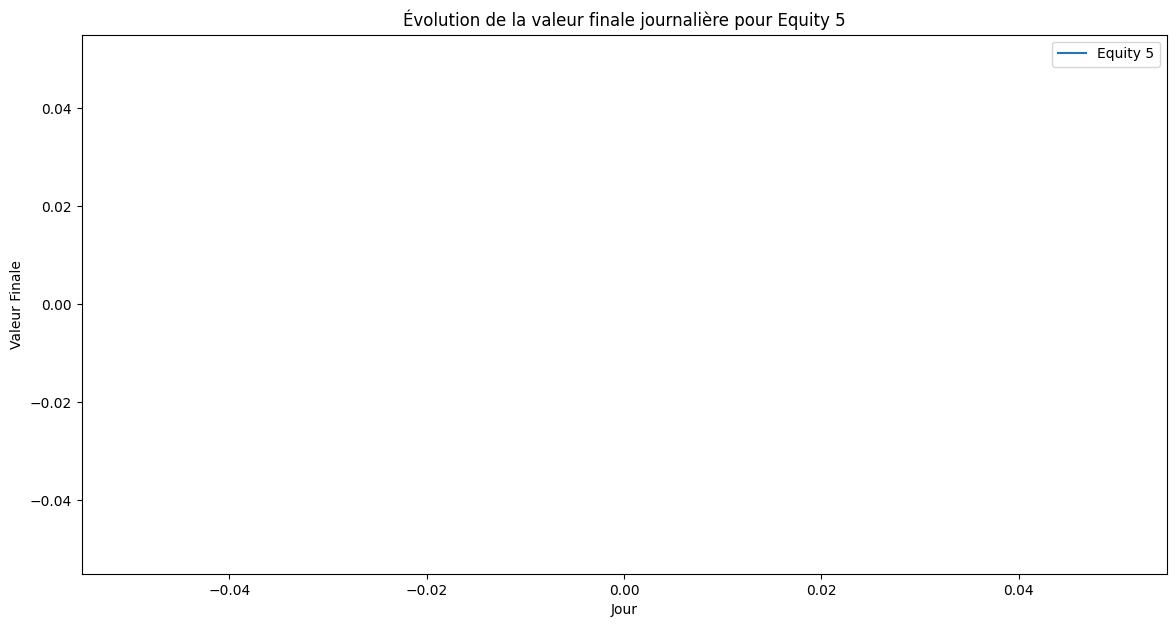

In [ ]:
# Convert the returns in growth rate
for i in range(1, 53):
    df.loc[:, f'r{i}'] = 1 + df[f'r{i}'].fillna(0) / 100

df.loc[:, 'value'] = df.loc[:, [f'r{i}' for i in range(1, 53)]].cumprod(axis=1).iloc[:, -1]

# Equity '5' / graph
equity_5_data = df[df['equity'] == 5]

plt.figure(figsize=(14, 7))
plt.plot(equity_5_data['day'], equity_5_data['value'], label='Equity 5')

plt.title('Évolution de la valeur finale journalière pour Equity 5')
plt.xlabel('Jour')
plt.ylabel('Valeur Finale')
plt.legend()
plt.show()

In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 98460 entries, 0 to 99999
Data columns (total 56 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      98460 non-null  int64  
 1   day     98460 non-null  int64  
 2   equity  98460 non-null  int64  
 3   r0      93571 non-null  float64
 4   r1      98272 non-null  float64
 5   r2      98242 non-null  float64
 6   r3      98316 non-null  float64
 7   r4      98304 non-null  float64
 8   r5      98284 non-null  float64
 9   r6      98269 non-null  float64
 10  r7      98288 non-null  float64
 11  r8      98300 non-null  float64
 12  r9      98296 non-null  float64
 13  r10     98277 non-null  float64
 14  r11     98298 non-null  float64
 15  r12     98292 non-null  float64
 16  r13     98294 non-null  float64
 17  r14     98270 non-null  float64
 18  r15     98262 non-null  float64
 19  r16     98276 non-null  float64
 20  r17     98287 non-null  float64
 21  r18     98263 non-null  float64
 22